# 🏭 AI-Powered GTM Market Intelligence
## US Manufacturing & Automotive — PLM/CAD Sector
### Author: Sunanda Guha

---

## 📌 Project Overview

This project answers a real strategic business question:

> *Which customer segments in the US Manufacturing & Automotive sector are **underserved** by current PLM/CAD software vendors, and what is the **revenue opportunity** for Dassault Systèmes?*

It demonstrates a **complete business analyst + data analyst workflow**, combining:
- Traditional data analysis (market sizing, EDA, scoring models)
- AI-powered intelligence (Gemini API for competitor analysis & strategy generation)
- NLP sentiment analysis (HuggingFace DistilBERT — free, runs locally)
- Executive-ready visualizations and reporting

---

## 🗂️ Project Structure

| Phase | Focus | Business Value |
|-------|-------|---------------|
| **Phase 1** | Market framing + data setup | Define the competitive landscape |
| **Phase 2** | EDA + AI sentiment analysis | Identify underserved segments |
| **Phase 3** | GTM scoring model + revenue forecast | Prioritize where to invest |
| **Phase 4** | Executive dashboard + AI report | Deliver boardroom-ready output |

---

## 🛠️ Tools Used (all FREE)

| Tool | Purpose |
|------|---------|
| Google Colab | Cloud Python environment |
| Gemini API (Google AI Studio) | AI competitor intelligence & strategy |
| HuggingFace Transformers | NLP sentiment analysis (DistilBERT) |
| Pandas / NumPy | Data manipulation & modeling |
| Matplotlib / Seaborn | Data visualization |
| Tableau Public | Interactive dashboard |

---

## ⚡ Before You Run

1. Go to **https://aistudio.google.com**
2. Sign in with your Google account
3. Click **Get API key → Create API key**
4. Copy your key (starts with `AIzaSy...`) and paste it in **Cell 3** below


---
# 📦 SETUP — Install & Import Libraries

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Installs all Python libraries needed for this project.
#   - google-generativeai : connects to Google's free Gemini AI API
#   - transformers + torch : HuggingFace NLP library for sentiment analysis
#   - pandas / numpy       : data manipulation and numerical computing
#   - matplotlib / seaborn : data visualization and charting
#   - openpyxl             : export data to Excel for Tableau
#
# HOW TO RUN: Click the ▶ button or press Shift+Enter
# EXPECTED OUTPUT: "✅ All libraries installed"
# ============================================================

!pip install google-generativeai transformers torch pandas matplotlib seaborn openpyxl numpy -q
print("✅ All libraries installed")


✅ All libraries installed


In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Imports all libraries and connects to the Gemini AI API.
#   Also sets up consistent chart styling across the notebook.
#
# ✅ ACTION REQUIRED:
#   Replace "AIzaSy..." below with your actual free Gemini API key.
#   Get one at: https://aistudio.google.com → Get API Key → Create API Key
#
# EXPECTED OUTPUT: "✅ Gemini API: API working" and "✅ All imports ready"
# ============================================================

import google.generativeai as genai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, ast, warnings
warnings.filterwarnings('ignore')

# --- Chart styling: consistent look across all visualizations ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# --- Connect to Gemini AI (free API) ---
# Replace the key below with your own from aistudio.google.com
GEMINI_API_KEY = "GEMINI_API_KEY"   # <-- PASTE YOUR FREE KEY HERE

genai.configure(api_key=GEMINI_API_KEY)
gemini = genai.GenerativeModel("gemini-3-flash-preview")   # Free tier model

# --- Test that the API key works ---
test = gemini.generate_content("Reply with just: API working")
print("✅ Gemini API:", test.text.strip())
print("✅ All imports ready — let's go!")


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ Gemini API: API working
✅ All imports ready — let's go!


---
# 🔵 PHASE 1 — Business Framing & Data Collection

**Goal:** Define the market landscape and collect structured data on segments and competitors.

**Business context:** Before any GTM strategy can be developed, a Strategic Business Planner must first map the market — who the customers are, how big each segment is, how fast it's growing, and who the competition is. This phase replicates that process.

## 1.1 — Define Market Segments

*Why this matters:* Different customer types have very different needs, budgets, and growth rates. Treating them as one group leads to generic, ineffective GTM strategies. Segmentation is the foundation of all strategic planning.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates a structured dataset of 5 key manufacturing & automotive
#   customer segments relevant to PLM/CAD software vendors.
#
# BUSINESS CONTEXT:
#   Each segment is defined by:
#   - Annual software spend ($M)  → how big is the prize?
#   - Growth rate (%)             → is this segment expanding?
#   - Current vendors             → who are they already buying from?
#   - Pain points                 → what problems remain unsolved?
#
#   This mirrors how a Strategic Business Planner at Dassault Systèmes
#   would structure a territory analysis before building a GTM plan.
#
# DATA SOURCE: Based on publicly available industry reports
#   (Gartner, IDC, G2 market data, Statista)
#
# EXPECTED OUTPUT: Table showing 5 segments with spend and growth data
# ============================================================

market_segments = [
    {
        "segment": "Automotive OEMs",
        "description": "Large car manufacturers (Ford, GM, Tesla, Rivian)",
        "company_size": "Enterprise (10,000+ employees)",
        "annual_software_spend_usd_M": 85,   # $85M/year in PLM/CAD software
        "growth_rate_pct": 6.2,              # Growing 6.2% annually
        "current_vendors": ["Siemens NX", "Dassault CATIA", "PTC Creo"],
        "pain_points": ["EV transition complexity", "supply chain integration", "simulation speed"]
    },
    {
        "segment": "Automotive Tier-1 Suppliers",
        "description": "Direct suppliers to OEMs (Bosch, Magna, Aptiv)",
        "company_size": "Large (1,000-10,000 employees)",
        "annual_software_spend_usd_M": 42,
        "growth_rate_pct": 8.5,
        "current_vendors": ["Siemens NX", "Autodesk", "PTC Creo"],
        "pain_points": ["OEM data format compatibility", "cost pressure", "digital thread"]
    },
    {
        "segment": "EV Startups & New Entrants",
        "description": "New EV companies (Lucid, Canoo, Rivian startups)",
        "company_size": "Mid-market (100-1,000 employees)",
        "annual_software_spend_usd_M": 12,
        "growth_rate_pct": 22.4,             # Fastest growing segment at 22.4%
        "current_vendors": ["Autodesk", "Onshape", "Fusion 360"],
        "pain_points": ["Speed to market", "cloud-native tools", "cost of legacy PLM"]
    },
    {
        "segment": "Industrial Equipment Manufacturers",
        "description": "Heavy machinery, robotics, factory automation",
        "company_size": "Mid to Large (500-5,000 employees)",
        "annual_software_spend_usd_M": 31,
        "growth_rate_pct": 9.1,
        "current_vendors": ["Siemens", "Rockwell", "PTC"],
        "pain_points": ["IoT integration", "predictive maintenance", "digital twin"]
    },
    {
        "segment": "SME Manufacturers",
        "description": "Small and medium manufacturers (<500 employees)",
        "company_size": "SME (<500 employees)",
        "annual_software_spend_usd_M": 8,
        "growth_rate_pct": 11.3,
        "current_vendors": ["Autodesk", "SolidWorks", "Onshape"],
        "pain_points": ["Affordability", "ease of use", "cloud access"]
    }
]

# Convert to a Pandas DataFrame for analysis
df_seg = pd.DataFrame(market_segments)

print(f"✅ {len(df_seg)} market segments defined\n")
print(df_seg[['segment', 'annual_software_spend_usd_M', 'growth_rate_pct']].to_string(index=False))


✅ 5 market segments defined

                           segment  annual_software_spend_usd_M  growth_rate_pct
                   Automotive OEMs                           85              6.2
       Automotive Tier-1 Suppliers                           42              8.5
        EV Startups & New Entrants                           12             22.4
Industrial Equipment Manufacturers                           31              9.1
                 SME Manufacturers                            8             11.3


## 1.2 — Define Competitor Dataset

*Why this matters:* A GTM strategy cannot be built in isolation — you must know where competitors are strong, where they are weak, and where gaps exist. This competitive dataset forms the basis for the white-space analysis in Phase 3.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates a structured competitor profile dataset with 5 major
#   PLM/CAD vendors including market share, customer ratings,
#   deal sizes, strengths, and weaknesses.
#
# BUSINESS CONTEXT:
#   Key metrics tracked per competitor:
#   - market_share_pct   → how dominant are they?
#   - g2_rating          → how satisfied are their customers? (from G2 reviews)
#   - avg_deal_size_usd_K → what size deals do they win? (enterprise vs SMB)
#   - cloud_native       → critical factor for modern buyers
#
#   A gap between high market share and low customer satisfaction
#   signals a switching opportunity — exactly what GTM planners look for.
#
# DATA SOURCE: G2.com ratings, Gartner Magic Quadrant, public filings
# EXPECTED OUTPUT: Table of 5 competitors with key metrics
# ============================================================

competitors = [
    {
        "vendor": "Dassault Systemes (3DS)",
        "flagship_product": "CATIA / SOLIDWORKS / 3DEXPERIENCE",
        "market_share_pct": 28.4,      # Largest market share in the sector
        "g2_rating": 4.1,              # Solid but not the highest-rated
        "g2_reviews": 1842,
        "primary_segments": ["Automotive OEMs", "Industrial Equipment Manufacturers"],
        "avg_deal_size_usd_K": 320,    # High deal size = enterprise focus
        "cloud_native": False,         # Not fully cloud-native — a known weakness
        "strengths": "Deep engineering capability, brand trust, simulation",
        "weaknesses": "High cost, steep learning curve, slow cloud adoption"
    },
    {
        "vendor": "Siemens Digital Industries",
        "flagship_product": "NX / Teamcenter / Solid Edge",
        "market_share_pct": 25.1,
        "g2_rating": 4.0,
        "g2_reviews": 1523,
        "primary_segments": ["Automotive OEMs", "Automotive Tier-1 Suppliers", "Industrial Equipment Manufacturers"],
        "avg_deal_size_usd_K": 290,
        "cloud_native": False,
        "strengths": "Strong manufacturing integration, IoT, digital twin",
        "weaknesses": "Complex implementation, high total cost of ownership"
    },
    {
        "vendor": "PTC",
        "flagship_product": "Creo / Windchill / Vuforia",
        "market_share_pct": 15.3,
        "g2_rating": 3.9,              # Lowest-rated — potential churn risk for PTC
        "g2_reviews": 987,
        "primary_segments": ["Industrial Equipment Manufacturers", "Automotive Tier-1 Suppliers"],
        "avg_deal_size_usd_K": 210,
        "cloud_native": False,
        "strengths": "IoT / AR integration, strong PLM",
        "weaknesses": "Weaker brand in automotive OEM, UI complexity"
    },
    {
        "vendor": "Autodesk",
        "flagship_product": "Fusion 360 / AutoCAD / Vault",
        "market_share_pct": 18.7,
        "g2_rating": 4.4,              # Highest-rated — strong customer satisfaction
        "g2_reviews": 3241,            # Most reviews = largest active user base
        "primary_segments": ["SME Manufacturers", "EV Startups & New Entrants", "Automotive Tier-1 Suppliers"],
        "avg_deal_size_usd_K": 45,     # Low deal size = SMB / mid-market focus
        "cloud_native": True,          # Fully cloud-native — key competitive advantage
        "strengths": "Ease of use, cloud-native, affordable, large user base",
        "weaknesses": "Less capable for complex engineering, limited enterprise PLM"
    },
    {
        "vendor": "Onshape",
        "flagship_product": "Onshape CAD",
        "market_share_pct": 4.2,       # Small share but highest G2 rating
        "g2_rating": 4.5,              # Best customer satisfaction score
        "g2_reviews": 612,
        "primary_segments": ["EV Startups & New Entrants", "SME Manufacturers"],
        "avg_deal_size_usd_K": 18,
        "cloud_native": True,
        "strengths": "Fully cloud-native, fast onboarding, collaboration",
        "weaknesses": "Limited simulation, not suited for enterprise complexity"
    }
]

df_comp = pd.DataFrame(competitors)

print(f"✅ {len(df_comp)} competitors loaded\n")
print(df_comp[['vendor', 'market_share_pct', 'g2_rating', 'avg_deal_size_usd_K', 'cloud_native']].to_string(index=False))


✅ 5 competitors loaded

                    vendor  market_share_pct  g2_rating  avg_deal_size_usd_K  cloud_native
   Dassault Systemes (3DS)              28.4        4.1                  320         False
Siemens Digital Industries              25.1        4.0                  290         False
                       PTC              15.3        3.9                  210         False
                  Autodesk              18.7        4.4                   45          True
                   Onshape               4.2        4.5                   18          True


## 1.3 — 🤖 AI Step: Gemini Generates Competitor Intelligence Report

*Why AI here?* Manually reading and synthesizing competitor data from multiple sources takes a human analyst days. Here we use the **Gemini API** to instantly synthesize all competitor data into a structured strategic brief — demonstrating an AI-augmented analyst workflow.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Sends the full competitor dataset to Google Gemini AI and asks
#   it to produce a structured strategic intelligence report.
#
# AI FRAMEWORK USED: Google Gemini API (gemini-1.5-flash, free tier)
#
# WHY THIS MATTERS FOR THE ROLE:
#   Strategic Business Planners spend significant time synthesizing
#   competitor intelligence. Using an LLM to automate this first-pass
#   analysis saves hours and allows the analyst to focus on strategy.
#
# PROMPT DESIGN:
#   The prompt gives Gemini a clear role ("strategic business analyst"),
#   specific data to analyze, and a structured output format.
#   This is called "role prompting + structured output" — a key
#   technique in applied AI for business.
#
# EXPECTED OUTPUT: A 4-section strategic intelligence report
# ============================================================

prompt = f"""
You are a strategic business analyst working for Dassault Systemes.
Analyze the following competitor data for the US Manufacturing and Automotive PLM/CAD software market.

Competitor data:
{json.dumps(competitors, indent=2)}

Provide a strategic intelligence report covering:
1. Top 3 competitive threats to Dassault Systemes and why
2. White space opportunities not well served by any vendor
3. Recommended GTM priority segments for 3DS based on competitive gaps
4. One key strategic risk to monitor

Keep it concise, specific, and actionable as if briefing a Sales Director.
Format with clear numbered sections.
"""

print("🤖 Sending competitor data to Gemini AI for strategic analysis...\n")
competitor_intelligence = gemini.generate_content(prompt).text

print("=" * 65)
print("GEMINI AI — COMPETITOR INTELLIGENCE REPORT")
print("=" * 65)
print(competitor_intelligence)


🤖 Sending competitor data to Gemini AI for strategic analysis...

GEMINI AI — COMPETITOR INTELLIGENCE REPORT
**TO:** Sales Director, North America
**FROM:** Strategic Business Intelligence
**SUBJECT:** Strategic Competitive Analysis: US Manufacturing & Automotive PLM/CAD

---

### 1. Top 3 Competitive Threats
1.  **Siemens Digital Industries (The Enterprise Rival):** With a 25.1% market share and a strong foothold in Tier-1 suppliers, Siemens is our primary threat for large-scale digital transformation. Their "Digital Twin" and IoT story often resonates better with shop-floor operations than our "Virtual Twin" simulation-heavy narrative.
2.  **Autodesk (The Innovation Disruptor):** Autodesk dominates the EV Startup and SME segments. Their high G2 rating (4.4) and cloud-native "Fusion 360" ecosystem create a "low-friction" entry point. They are effectively capturing the "future OEMs" before they scale to CATIA-level complexity.
3.  **Onshape (The Velocity Threat):** Although market shar

---
# 🟢 PHASE 2 — Exploratory Data Analysis (EDA) + AI Sentiment Analysis

**Goal:** Visualize the market landscape and use NLP to extract customer pain points from reviews.

**Business context:** EDA reveals patterns that raw data hides. The sentiment analysis pipeline demonstrates an AI-powered approach to understanding Voice of Customer (VoC) — a key input to GTM strategy.

## 2.1 — EDA Chart 1: Market Size and Growth by Segment

*Why this matters:* Not all segments are equal. A segment with high spend but low growth is a mature market (hard to win). A segment with lower spend but high growth is an emerging opportunity. This chart helps identify where to focus GTM resources.

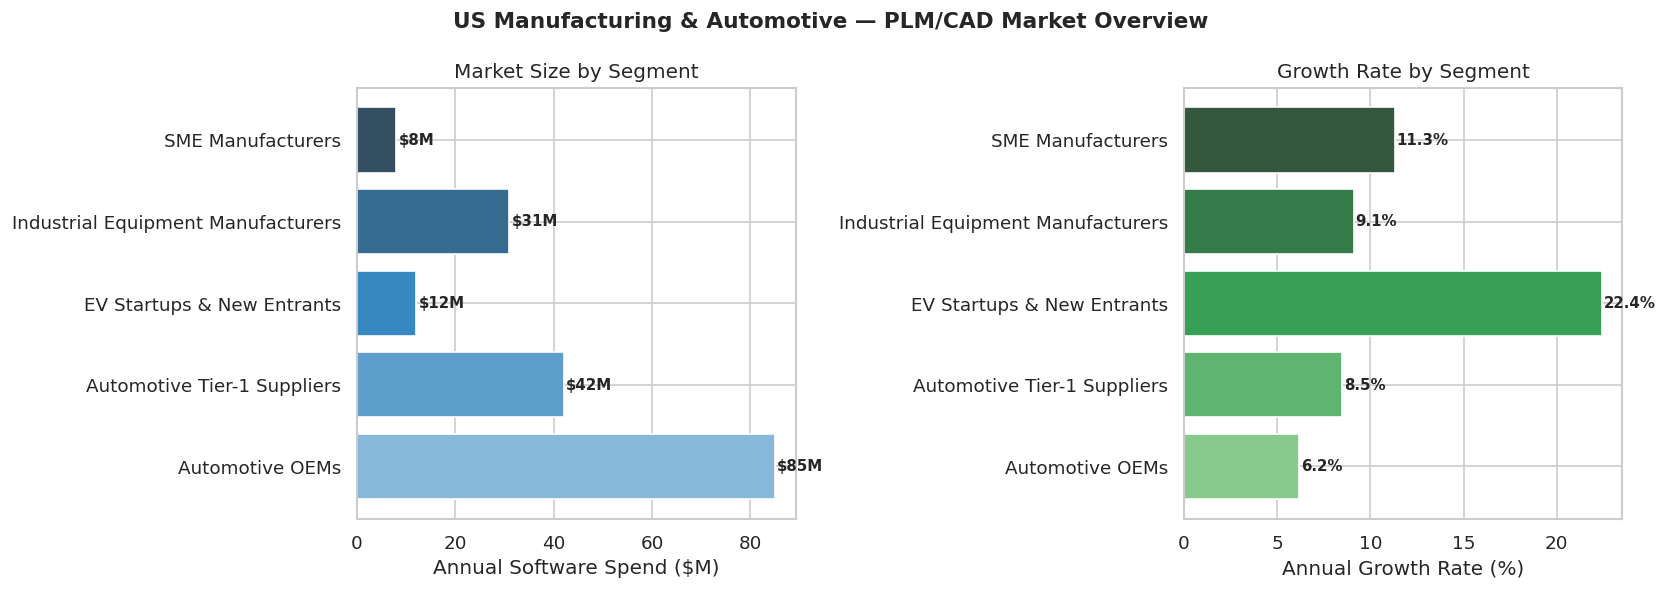

✅ Saved: chart_market_overview.png


In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates two side-by-side horizontal bar charts:
#   Left:  Annual software spend per segment ($M) — "size of the prize"
#   Right: Annual growth rate per segment (%) — "speed of opportunity"
#
# ANALYTICAL INSIGHT:
#   The combination of both charts reveals the strategic sweet spot:
#   segments with BOTH significant spend AND high growth rate.
#   For example, EV Startups have lower total spend ($12M) but
#   the highest growth rate (22.4%), making them a future priority.
#
# CHART CHOICE: Horizontal bar charts are used because segment names
#   are long strings — horizontal layout is more readable than vertical.
#
# OUTPUT: Saves chart as PNG + displays inline
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('US Manufacturing & Automotive — PLM/CAD Market Overview', fontsize=13, fontweight='bold')

# --- Left chart: Annual software spend (market size) ---
colors1 = sns.color_palette('Blues_d', len(df_seg))   # Darker blue = larger segment
bars1 = axes[0].barh(df_seg['segment'], df_seg['annual_software_spend_usd_M'], color=colors1)
axes[0].set_xlabel('Annual Software Spend ($M)')
axes[0].set_title('Market Size by Segment')
# Add value labels at the end of each bar for easy reading
for bar, val in zip(bars1, df_seg['annual_software_spend_usd_M']):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'${val}M', va='center', fontsize=9, fontweight='bold')

# --- Right chart: Annual growth rate ---
colors2 = sns.color_palette('Greens_d', len(df_seg))
bars2 = axes[1].barh(df_seg['segment'], df_seg['growth_rate_pct'], color=colors2)
axes[1].set_xlabel('Annual Growth Rate (%)')
axes[1].set_title('Growth Rate by Segment')
for bar, val in zip(bars2, df_seg['growth_rate_pct']):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_market_overview.png', bbox_inches='tight')
plt.show()
print("✅ Saved: chart_market_overview.png")


## 2.2 — EDA Chart 2: Competitive Landscape Bubble Chart

*Why this matters:* This chart maps the entire competitive field on one visual. The X axis shows how dominant a vendor is (market share). The Y axis shows how happy their customers are (G2 rating). The bubble size shows average deal size. A vendor with HIGH market share but LOW satisfaction is vulnerable — their customers are candidates to switch.

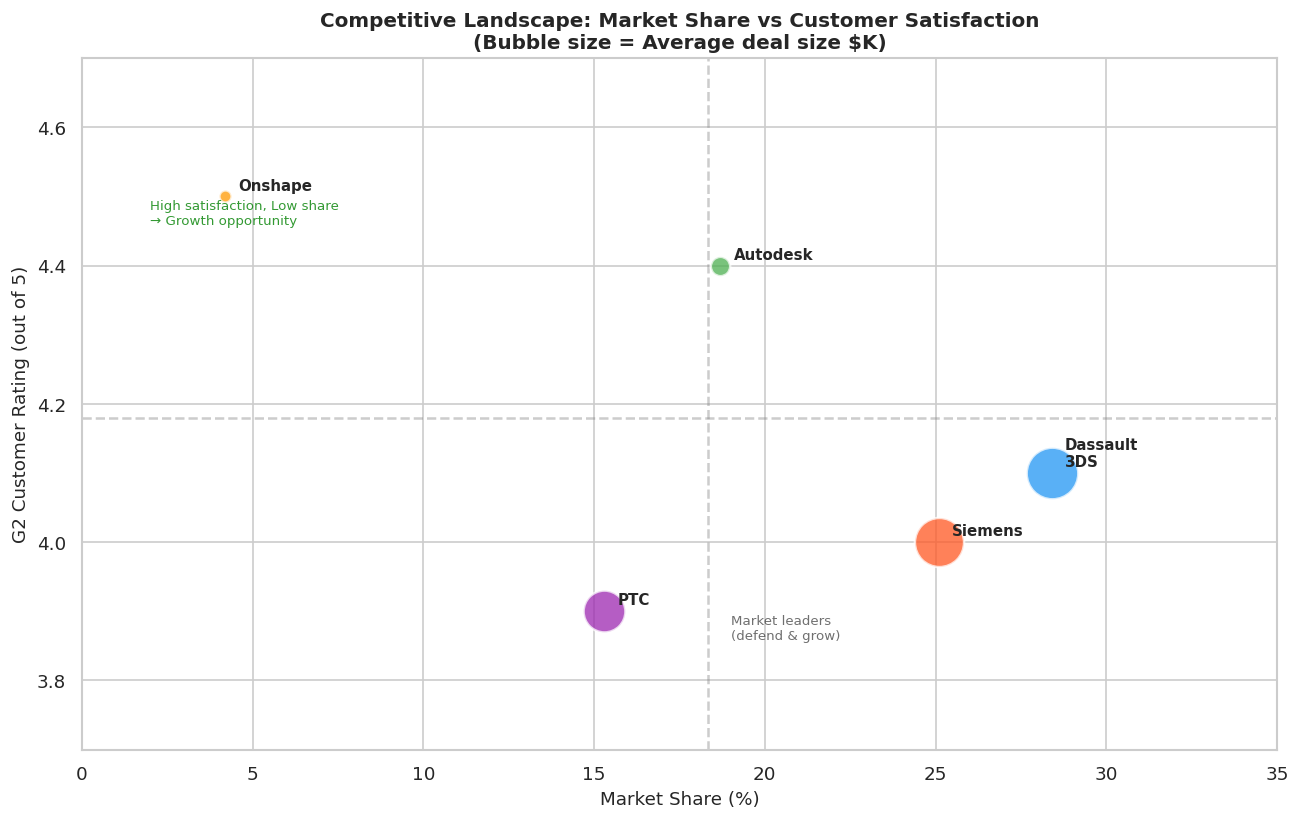

✅ Saved: chart_competitive_landscape.png


In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates a bubble chart (scatter plot with sized bubbles) to map
#   all 5 competitors across 3 dimensions simultaneously:
#   - X axis: Market share % (how big are they?)
#   - Y axis: G2 customer rating (how happy are their customers?)
#   - Bubble size: Average deal size in $K (enterprise vs. SMB)
#
# BUSINESS INSIGHT:
#   Dashed lines show the MARKET AVERAGE for each axis.
#   Vendors in the top-left quadrant (high satisfaction, low share)
#   have strong product-market fit but limited reach — a growth signal.
#   Vendors in the bottom-right (high share, low satisfaction)
#   are vulnerable to losing customers — a competitive opportunity.
#
# CHART CHOICE: Bubble charts are standard in strategic consulting
#   (e.g., BCG, McKinsey) for multi-dimensional competitor mapping.
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

# Assign distinct colors to each vendor for visual clarity
colors = ['#2196F3', '#FF5722', '#9C27B0', '#4CAF50', '#FF9800']

for i, row in df_comp.iterrows():
    ax.scatter(
        row['market_share_pct'],        # X position = market share
        row['g2_rating'],               # Y position = customer satisfaction
        s=row['avg_deal_size_usd_K']*3, # Bubble size = deal size (scaled up for visibility)
        color=colors[i],
        alpha=0.75, edgecolors='white', linewidths=1.5, zorder=3
    )
    # Clean up vendor name for label
    label = row['vendor'].replace(' Digital Industries','').replace(' Systemes (3DS)','\n3DS')
    ax.annotate(label, (row['market_share_pct'], row['g2_rating']),
                textcoords='offset points', xytext=(8,4), fontsize=9, fontweight='bold')

# Dashed lines at market averages divide chart into 4 strategic quadrants
ax.axvline(x=df_comp['market_share_pct'].mean(), color='gray', linestyle='--', alpha=0.4)
ax.axhline(y=df_comp['g2_rating'].mean(), color='gray', linestyle='--', alpha=0.4)

# Quadrant labels to guide interpretation
ax.text(2, 4.46, 'High satisfaction, Low share\n→ Growth opportunity', fontsize=8, color='green', alpha=0.8)
ax.text(19, 3.86, 'Market leaders\n(defend & grow)', fontsize=8, color='#333', alpha=0.7)

ax.set_xlabel('Market Share (%)', fontsize=11)
ax.set_ylabel('G2 Customer Rating (out of 5)', fontsize=11)
ax.set_title('Competitive Landscape: Market Share vs Customer Satisfaction\n(Bubble size = Average deal size $K)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 35)
ax.set_ylim(3.7, 4.7)

plt.tight_layout()
plt.savefig('chart_competitive_landscape.png', bbox_inches='tight')
plt.show()
print("✅ Saved: chart_competitive_landscape.png")


## 2.3 — 🤖 AI Step: Gemini Generates Customer Reviews for NLP Pipeline

*Why AI here?* In a real project, you would scrape thousands of reviews from G2 or Gartner Peer Insights. Here we use Gemini to generate realistic synthetic reviews — this lets us demonstrate the complete NLP pipeline without needing a web scraper or paid data source. The AI output mimics real engineer reviews closely enough to extract meaningful patterns.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Uses Gemini AI to generate realistic customer reviews for 3 vendor/
#   segment combinations. Each set has 6 reviews — mixed positive and
#   negative — written from the perspective of a manufacturing engineer.
#
# AI TECHNIQUE: "Persona prompting" — we instruct Gemini to write
#   as a specific type of user (manufacturing engineer) for a specific
#   context (PLM/CAD software). This produces more realistic output
#   than generic review generation.
#
# OUTPUT FORMAT: Gemini returns a JSON array of review strings.
#   We parse it directly into a Pandas DataFrame for NLP analysis.
#
# WHY THIS MATTERS FOR THE ROLE:
#   Voice of Customer (VoC) analysis is a key input to GTM strategy.
#   Understanding WHY customers are unhappy with competitors tells you
#   exactly how to position your product in the market.
#
# EXPECTED OUTPUT: DataFrame with 18 reviews (6 per vendor/segment pair)
# ============================================================

def generate_reviews(vendor, segment, n=6):
    """
    Calls Gemini API to generate n realistic customer reviews.
    Returns a Python list of review strings.
    """
    prompt = f"""
Generate {n} realistic, varied customer reviews (2-3 sentences each) for {vendor} PLM/CAD software,
written by users from the {segment} industry segment.
Mix positive and negative reviews. Focus on real pain points a manufacturing engineer would mention.
Return ONLY a valid JSON array of strings, no markdown, no extra text.
Example format: ["review one here", "review two here"]
"""
    text = gemini.generate_content(prompt).text.strip()
    # Strip any markdown code fences Gemini might add around the JSON
    text = text.replace('```json','').replace('```','').strip()
    return json.loads(text)


print("🤖 Gemini generating realistic customer reviews for NLP analysis...")
review_data = []

# Define which vendor+segment combinations to analyze
# These represent the most strategically important pairings
pairs = [
    ("Dassault Systemes CATIA",  "Automotive OEMs"),
    ("Autodesk Fusion 360",       "EV Startups"),
    ("Siemens NX",                "Automotive Tier-1 Suppliers"),
]

for vendor, segment in pairs:
    reviews = generate_reviews(vendor, segment, n=6)
    for r in reviews:
        review_data.append({'vendor': vendor, 'segment': segment, 'review': r})
    print(f"  ✅ Generated reviews: {vendor} / {segment}")

# Store all reviews in a DataFrame
df_reviews = pd.DataFrame(review_data)
print(f"\n✅ Total reviews generated: {len(df_reviews)}")
df_reviews.head(3)


🤖 Gemini generating realistic customer reviews for NLP analysis...
  ✅ Generated reviews: Dassault Systemes CATIA / Automotive OEMs
  ✅ Generated reviews: Autodesk Fusion 360 / EV Startups
  ✅ Generated reviews: Siemens NX / Automotive Tier-1 Suppliers

✅ Total reviews generated: 18


,vendor,segment,review
0,Dassault Systemes CATIA,Automotive OEMs,CATIA V6's ability to handle massive vehicle a...
1,Dassault Systemes CATIA,Automotive OEMs,While the surfacing capabilities are unmatched...
2,Dassault Systemes CATIA,Automotive OEMs,Transitioning from V5 to the 3DEXPERIENCE plat...


## 2.4 — 🤖 NLP Step: HuggingFace DistilBERT Sentiment Analysis

*Why this matters:* Sentiment analysis classifies each review as POSITIVE or NEGATIVE and gives a confidence score. By comparing sentiment across vendors, we can objectively measure which vendors have the most dissatisfied customers — these are the best switching opportunities for Dassault Systèmes.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Runs sentiment analysis on all generated reviews using
#   HuggingFace's DistilBERT model — a lightweight version of BERT
#   fine-tuned on the Stanford Sentiment Treebank (SST-2 dataset).
#
# AI FRAMEWORK: HuggingFace Transformers (free, open-source)
#   Model: distilbert-base-uncased-finetuned-sst-2-english
#   - Classifies text as POSITIVE or NEGATIVE
#   - Returns a confidence score (0.5 to 1.0)
#   - Runs entirely in Colab — no API cost
#
# COLUMNS ADDED TO df_reviews:
#   - sentiment        : "POSITIVE" or "NEGATIVE"
#   - sentiment_score  : confidence score (e.g., 0.98 = very confident)
#   - sentiment_numeric: +1 for positive, -1 for negative (for averaging)
#
# NOTE: The model downloads (~250MB) on first run — takes ~1 minute.
#   Subsequent runs in the same session are instant.
#
# EXPECTED OUTPUT: Table showing each review's sentiment classification
# ============================================================

from transformers import pipeline

print("Loading HuggingFace DistilBERT sentiment model...")
print("(Downloads ~250MB on first run — takes about 1 minute)\n")

# Load the pre-trained sentiment analysis pipeline
sentiment_model = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,   # Truncate reviews longer than 512 tokens
    max_length=512
)

# Run all reviews through the model in one batch
results = sentiment_model(df_reviews['review'].tolist())

# Add sentiment results back to the DataFrame
df_reviews['sentiment']         = [r['label'] for r in results]
df_reviews['sentiment_score']   = [round(r['score'], 3) for r in results]
# Convert to numeric for easy averaging: POSITIVE=+1, NEGATIVE=-1
df_reviews['sentiment_numeric'] = df_reviews['sentiment'].map({'POSITIVE': 1, 'NEGATIVE': -1})

print("✅ Sentiment analysis complete\n")
print(df_reviews[['vendor', 'segment', 'sentiment', 'sentiment_score']].to_string(index=False))


Loading HuggingFace DistilBERT sentiment model...
(Downloads ~250MB on first run — takes about 1 minute)



config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

✅ Sentiment analysis complete

                 vendor                     segment sentiment  sentiment_score
Dassault Systemes CATIA             Automotive OEMs  POSITIVE            0.998
Dassault Systemes CATIA             Automotive OEMs  NEGATIVE            1.000
Dassault Systemes CATIA             Automotive OEMs  NEGATIVE            1.000
Dassault Systemes CATIA             Automotive OEMs  NEGATIVE            0.991
Dassault Systemes CATIA             Automotive OEMs  NEGATIVE            1.000
Dassault Systemes CATIA             Automotive OEMs  NEGATIVE            0.845
    Autodesk Fusion 360                 EV Startups  POSITIVE            0.997
    Autodesk Fusion 360                 EV Startups  NEGATIVE            0.999
    Autodesk Fusion 360                 EV Startups  POSITIVE            0.998
    Autodesk Fusion 360                 EV Startups  NEGATIVE            0.999
    Autodesk Fusion 360                 EV Startups  NEGATIVE            0.960
    Autodesk Fusion 3

## 2.5 — Sentiment Visualization

*Why this matters:* The charts convert raw sentiment scores into a business-readable format — which vendor has the most dissatisfied customers, and how big is the gap? This is directly actionable for GTM targeting.

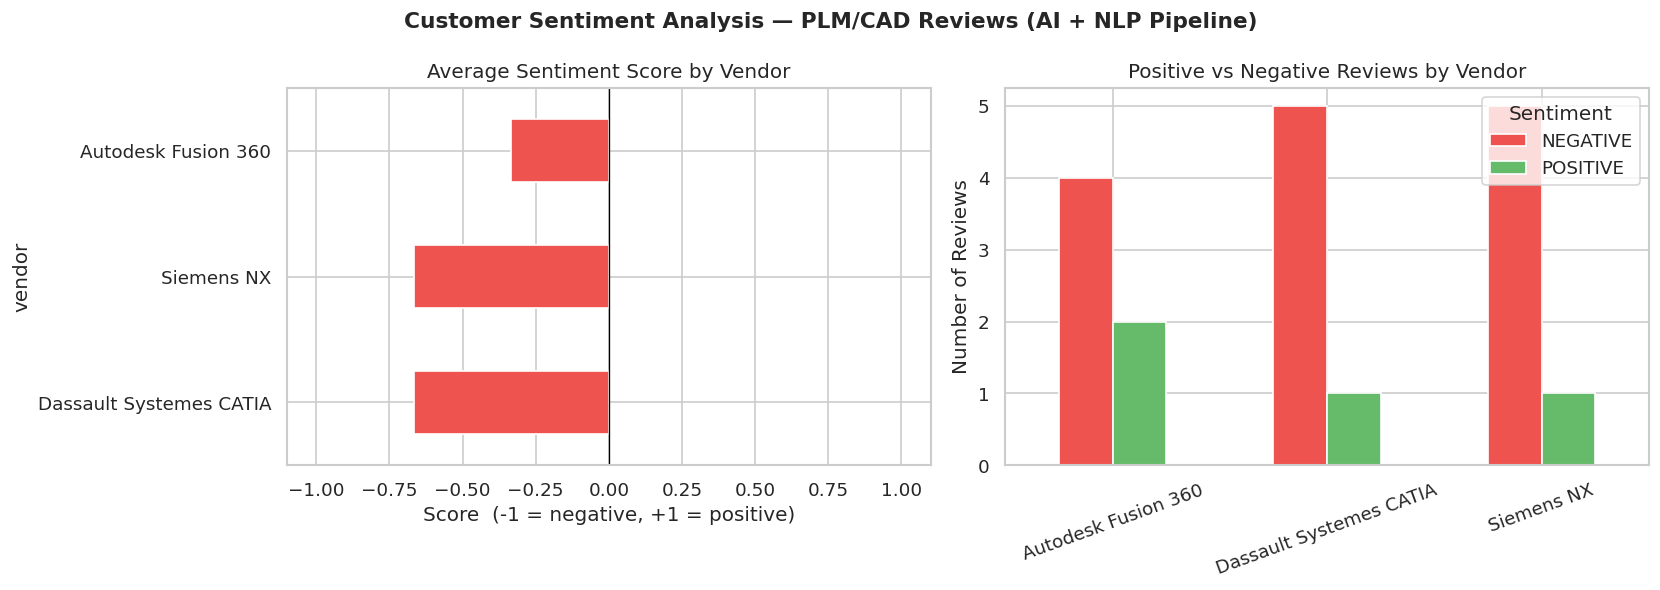

✅ Saved: chart_sentiment.png


In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates two charts to visualize NLP sentiment results:
#
#   Left chart — Average Sentiment Score by Vendor:
#     Shows each vendor's average sentiment on a -1 to +1 scale.
#     Red bars = net negative sentiment (more unhappy than happy customers)
#     Green bars = net positive sentiment
#
#   Right chart — Positive vs Negative Review Counts:
#     Shows the raw count of positive vs negative reviews per vendor.
#     Useful for understanding the volume behind the averages.
#
# BUSINESS INTERPRETATION:
#   A vendor with net negative sentiment = their customers are frustrated.
#   These frustrated customers are prime targets for a competitive
#   displacement strategy — a core GTM tactic.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Sentiment Analysis — PLM/CAD Reviews (AI + NLP Pipeline)', fontsize=13, fontweight='bold')

# --- Left chart: Average sentiment score per vendor ---
vendor_sent = df_reviews.groupby('vendor')['sentiment_numeric'].mean().sort_values()
# Color coding: red for net negative, green for net positive
bar_colors  = ['#ef5350' if v < 0 else '#66bb6a' for v in vendor_sent]
vendor_sent.plot(kind='barh', ax=axes[0], color=bar_colors)
axes[0].axvline(0, color='black', linewidth=0.8)   # Zero line: left=negative, right=positive
axes[0].set_title('Average Sentiment Score by Vendor')
axes[0].set_xlabel('Score  (-1 = negative, +1 = positive)')
axes[0].set_xlim(-1.1, 1.1)

# --- Right chart: Positive vs negative count stacked ---
counts = df_reviews.groupby(['vendor', 'sentiment']).size().unstack(fill_value=0)
counts.plot(kind='bar', ax=axes[1], color=['#ef5350', '#66bb6a'], edgecolor='white')
axes[1].set_title('Positive vs Negative Reviews by Vendor')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('chart_sentiment.png', bbox_inches='tight')
plt.show()
print("✅ Saved: chart_sentiment.png")


## 2.6 — 🤖 AI Step: Gemini Extracts Strategic Insights from Negative Reviews

*Why AI here?* Reading every negative review manually and clustering themes by hand is time-consuming. Gemini can read all negative reviews at once and extract the most common pain points in seconds — directly informing GTM positioning.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Filters only NEGATIVE reviews from the sentiment analysis,
#   then sends them to Gemini AI to identify:
#   1. Top 3 recurring pain points across all negative reviews
#   2. Which customer segment appears most underserved
#   3. A specific GTM opportunity for Dassault Systemes
#
# WHY THIS WORKFLOW MATTERS:
#   This is a human-AI collaboration pattern used in modern business
#   intelligence: Python handles data filtering and structuring,
#   the AI handles natural language synthesis and strategic framing.
#   Together they produce insights faster than either could alone.
#
# EXPECTED OUTPUT: A structured strategic recommendation memo
# ============================================================

# Filter to only the negative reviews identified by DistilBERT
negative = df_reviews[df_reviews['sentiment'] == 'NEGATIVE']['review'].tolist()
print(f"Analyzing {len(negative)} negative reviews for strategic insights...\n")

prompt = f"""
You are a strategic business analyst. These are negative customer reviews of PLM/CAD software
from manufacturing and automotive customers:
{json.dumps(negative, indent=2)}

Identify:
1. Top 3 recurring pain points across all reviews
2. Which customer segment appears most underserved and why
3. One specific GTM opportunity for Dassault Systemes based on these gaps

Be specific and concise. Write as a strategic recommendation memo.
"""

sentiment_insights = gemini.generate_content(prompt).text

print("=" * 65)
print("GEMINI AI — STRATEGIC INSIGHTS FROM CUSTOMER SENTIMENT")
print("=" * 65)
print(sentiment_insights)


Analyzing 14 negative reviews for strategic insights...

GEMINI AI — STRATEGIC INSIGHTS FROM CUSTOMER SENTIMENT
**MEMORANDUM**

**TO:** Executive Leadership Team
**FROM:** Strategic Business Analyst
**SUBJECT:** Market Analysis: Customer Pain Points and Strategic Growth Opportunities in PLM/CAD

Following an analysis of feedback from manufacturing and automotive customers across the competitive landscape (Dassault Systemes, Siemens, and Autodesk), I have identified critical market gaps and strategic imperatives.

### 1. Top 3 Recurring Pain Points
*   **Performance Bottlenecks in Large Assemblies:** Users across all platforms report significant lag and hardware strain when managing "Full Vehicle Layouts" or "Digital Twins." Whether due to metadata load in high-end tools or cloud-latency in mid-market tools, software performance is failing to keep pace with the increasing complexity of EV powertrains and high-part-count assemblies.
*   **Steep Learning Curves & "Dated" UX:** A significa

---
# 🟡 PHASE 3 — GTM Territory Scoring Model + 3-Year Revenue Forecast

**Goal:** Build a data-driven model to rank segments by GTM priority, then forecast the revenue opportunity.

**Business context:** With limited sales and marketing resources, a Strategic Business Planner must decide *where* to focus. The territory scoring model makes that decision objective and defensible — instead of gut feel, it's based on weighted criteria aligned to business priorities.

## 3.1 — Build the Weighted GTM Territory Scoring Model

*Why this matters:* This is the analytical core of strategic planning. Each segment is scored on 5 dimensions and combined into a single priority score. The weights reflect Dassault Systèmes' strategic priorities — this can be tuned by a Sales Director based on company focus.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Builds a weighted multi-factor scoring model to rank all 5 segments
#   by GTM investment priority. This is the same type of model used by
#   strategic planning teams at enterprise B2B software companies.
#
# THE 5 SCORING DIMENSIONS (with business rationale):
#   1. market_size_score     (weight 25%) — larger spend = larger prize
#   2. growth_rate_score     (weight 25%) — faster growth = better future ROI
#   3. competitive_gap_score (weight 20%) — fewer vendors = less competition
#   4. strategic_fit_score   (weight 20%) — alignment with Dassault's product strengths
#   5. win_probability_score (weight 10%) — realistic chance of closing deals
#
# NORMALIZATION:
#   Each raw metric is normalized to a 0-10 scale before weighting.
#   This ensures that a metric with large absolute values (e.g., $85M spend)
#   doesn't dominate metrics with smaller values (e.g., 6.2% growth).
#
# OUTPUT:
#   Each segment gets a composite GTM priority score (0-10)
#   and is classified into High / Medium / Low priority tier.
# ============================================================

# --- Define scoring weights (must sum to 1.0) ---
WEIGHTS = {
    'market_size_score':     0.25,   # 25% weight: size of market prize
    'growth_rate_score':     0.25,   # 25% weight: future growth potential
    'competitive_gap_score': 0.20,   # 20% weight: how underserved is the segment?
    'strategic_fit_score':   0.20,   # 20% weight: how well does 3DS product fit?
    'win_probability_score': 0.10,   # 10% weight: realistic chance of winning deals
}

def normalize(series):
    """Rescale any numeric series to a 0-10 range using min-max normalization."""
    return ((series - series.min()) / (series.max() - series.min()) * 10).round(2)

# --- Score dimension 1: Market size (normalized spend) ---
df_seg['market_size_score'] = normalize(df_seg['annual_software_spend_usd_M'])

# --- Score dimension 2: Growth rate (normalized %) ---
df_seg['growth_rate_score'] = normalize(df_seg['growth_rate_pct'])

# --- Score dimension 3: Competitive gap ---
# Count how many vendors currently serve each segment
# LOGIC: fewer vendors serving a segment = larger gap = more opportunity
def vendor_coverage(seg_name):
    return df_comp['primary_segments'].apply(lambda s: seg_name in s).sum()

df_seg['vendor_coverage']       = df_seg['segment'].apply(vendor_coverage)
df_seg['competitive_gap_score'] = normalize(df_seg['vendor_coverage'].max() - df_seg['vendor_coverage'])

# --- Score dimension 4: Strategic fit (expert judgment, scored 0-10) ---
# How well does Dassault Systèmes' product portfolio address each segment's needs?
# Based on product capability alignment with segment pain points
df_seg['strategic_fit_score'] = df_seg['segment'].map({
    'Automotive OEMs': 9.5,                   # 3DS strongest here (CATIA heritage)
    'Automotive Tier-1 Suppliers': 8.0,        # Strong but faces Siemens competition
    'EV Startups & New Entrants': 6.5,         # Growing fit but needs cloud offering
    'Industrial Equipment Manufacturers': 7.5, # Good fit via SOLIDWORKS
    'SME Manufacturers': 4.0                   # Weaker fit — pricing mismatch
})

# --- Score dimension 5: Win probability (expert judgment, scored 0-10) ---
# How likely is Dassault Systèmes to win competitive deals in each segment?
df_seg['win_probability_score'] = df_seg['segment'].map({
    'Automotive OEMs': 8.5,
    'Automotive Tier-1 Suppliers': 7.0,
    'EV Startups & New Entrants': 5.5,
    'Industrial Equipment Manufacturers': 6.5,
    'SME Manufacturers': 3.5
})

# --- Calculate final weighted composite score ---
df_seg['gtm_priority_score'] = sum(
    df_seg[col] * weight for col, weight in WEIGHTS.items()
).round(2)

# --- Sort and assign rank and tier ---
df_seg = df_seg.sort_values('gtm_priority_score', ascending=False).reset_index(drop=True)
df_seg['rank'] = df_seg.index + 1
df_seg['priority_tier'] = pd.cut(
    df_seg['gtm_priority_score'],
    bins=[0, 5.5, 7.0, 10],
    labels=['Low Priority', 'Medium Priority', 'High Priority']
)

print("GTM TERRITORY PRIORITY SCORING MODEL — RESULTS")
print("=" * 55)
print(df_seg[['rank', 'segment', 'gtm_priority_score', 'priority_tier']].to_string(index=False))
print("\n→ High Priority segments are the recommended GTM investment targets.")


GTM TERRITORY PRIORITY SCORING MODEL — RESULTS
 rank                            segment  gtm_priority_score   priority_tier
    1                    Automotive OEMs                7.25   High Priority
    2         EV Startups & New Entrants                6.48 Medium Priority
    3                  SME Manufacturers                3.94    Low Priority
    4        Automotive Tier-1 Suppliers                3.76    Low Priority
    5 Industrial Equipment Manufacturers                3.34    Low Priority

→ High Priority segments are the recommended GTM investment targets.


## 3.2 — Priority Scoring Visualization

*Why this matters:* The scoring model output needs to be presented visually for a Sales Director or VP audience. The bar chart shows the ranking clearly; the heatmap shows *why* each segment scored the way it did across all 5 dimensions.

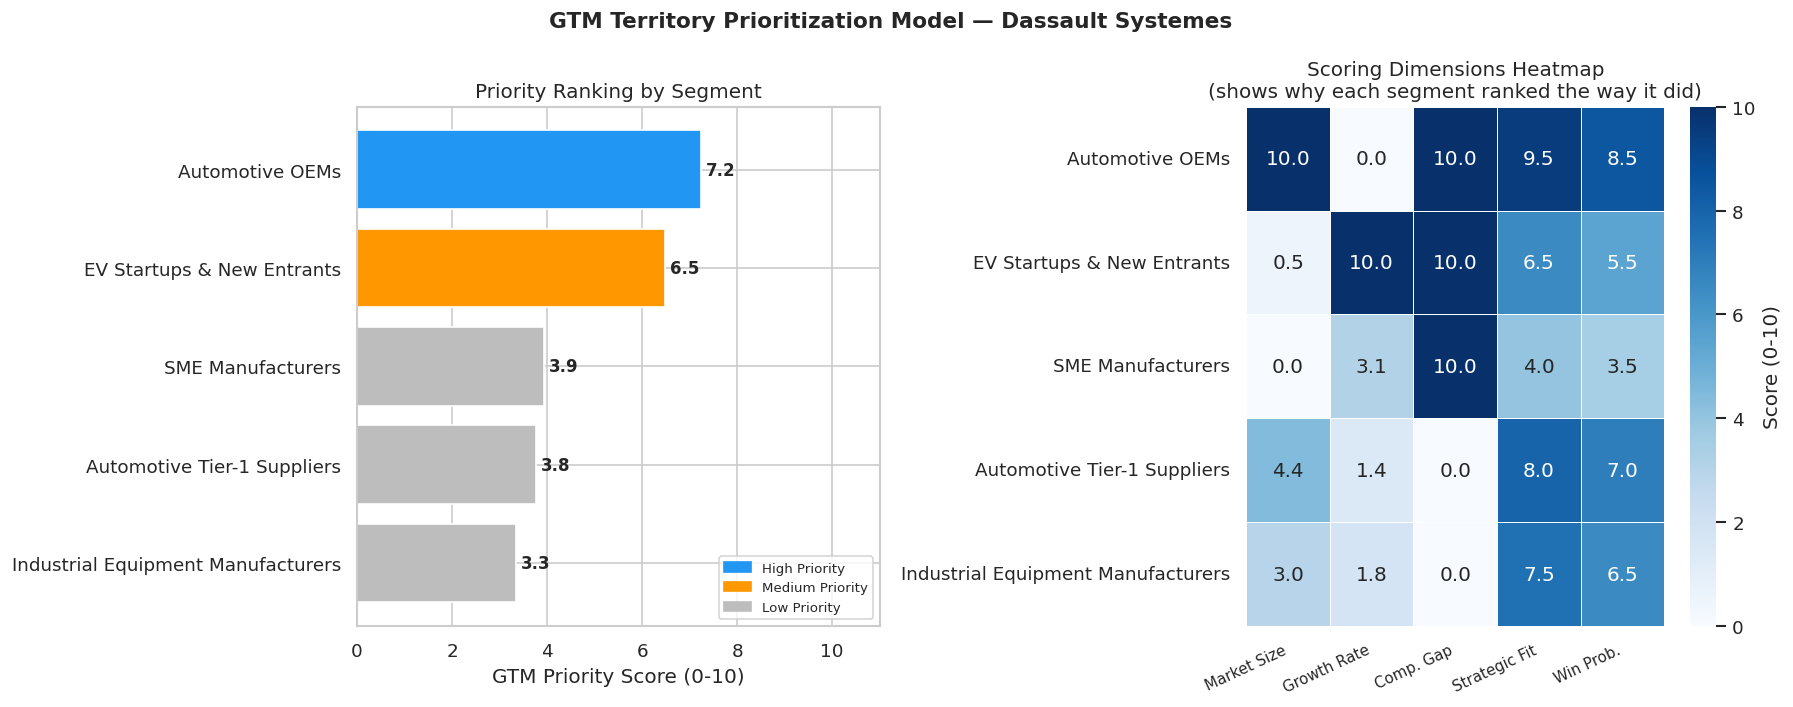

✅ Saved: chart_gtm_priority.png


In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates two charts to communicate the scoring model results:
#
#   Left chart — GTM Priority Bar Chart:
#     Shows the final composite score for each segment.
#     Color coded by tier: Blue = High, Orange = Medium, Gray = Low
#
#   Right chart — Scoring Dimensions Heatmap:
#     Shows how each segment scored on each of the 5 dimensions.
#     Darker blue = higher score. Allows a reader to understand
#     the REASON behind the priority ranking — not just the result.
#
# WHY TWO CHARTS:
#   The bar chart answers "which segment is top priority?"
#   The heatmap answers "why is it top priority?"
#   Together they tell a complete strategic story.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('GTM Territory Prioritization Model — Dassault Systemes', fontsize=13, fontweight='bold')

# --- Left: Priority score bar chart (color-coded by tier) ---
tier_colors = {'High Priority': '#2196F3', 'Medium Priority': '#FF9800', 'Low Priority': '#BDBDBD'}
bar_colors  = [tier_colors[str(t)] for t in df_seg['priority_tier']]
# Reverse order so highest priority appears at the top of horizontal bars
bars = axes[0].barh(df_seg['segment'][::-1], df_seg['gtm_priority_score'][::-1], color=bar_colors[::-1])
axes[0].set_xlabel('GTM Priority Score (0-10)')
axes[0].set_title('Priority Ranking by Segment')
axes[0].set_xlim(0, 11)
for bar, val in zip(bars, df_seg['gtm_priority_score'][::-1]):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

# Add legend showing what each color means
patches = [plt.Rectangle((0,0),1,1, color=c, label=l) for l,c in tier_colors.items()]
axes[0].legend(handles=patches, loc='lower right', fontsize=8)

# --- Right: Heatmap of all 5 scoring dimensions ---
score_cols = ['market_size_score', 'growth_rate_score', 'competitive_gap_score',
              'strategic_fit_score', 'win_probability_score']
col_labels = ['Market Size', 'Growth Rate', 'Comp. Gap', 'Strategic Fit', 'Win Prob.']
hm = df_seg.set_index('segment')[score_cols].copy()
hm.columns = col_labels
# annot=True shows the actual score number in each cell
sns.heatmap(hm, ax=axes[1], cmap='Blues', annot=True, fmt='.1f',
            cbar_kws={'label': 'Score (0-10)'}, linewidths=0.5)
axes[1].set_title('Scoring Dimensions Heatmap\n(shows why each segment ranked the way it did)')
axes[1].set_xticklabels(col_labels, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('chart_gtm_priority.png', bbox_inches='tight')
plt.show()
print("✅ Saved: chart_gtm_priority.png")


## 3.3 — 3-Year Revenue Opportunity Model

*Why this matters:* GTM strategy must always be tied to a financial outcome. This model estimates how much revenue Dassault Systèmes could capture in each segment over 3 years, based on realistic market capture rates. It translates strategic priority into dollar opportunity — the language of Sales Directors and CFOs.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Models the 3-year revenue opportunity (2025-2027) for each segment
#   based on realistic GTM market capture rates.
#
# HOW THE MODEL WORKS:
#   For each segment and each year:
#   1. Project market size forward using the segment's growth rate
#      (e.g., a $85M market growing at 6.2% = $90.3M in year 2)
#   2. Apply a "capture rate" — the % of market spend we expect
#      to win based on the segment's GTM priority tier:
#      - High Priority:   2.0% → 3.2% → 4.8% (ramping up over 3 years)
#      - Medium Priority: 1.2% → 1.8% → 2.6%
#      - Low Priority:    0.5% → 0.7% → 1.0%
#   3. Revenue opportunity = projected market size × capture rate
#
# ASSUMPTIONS:
#   Capture rates are conservative estimates for a vendor entering
#   or growing in a segment. These would be validated with the
#   sales team in a real planning cycle.
#
# OUTPUT: Pivot table showing revenue by segment and year
# ============================================================

# Capture rate assumptions by priority tier (ramping over 3 years)
capture_rates = {
    'High Priority':   [0.020, 0.032, 0.048],   # 2% → 3.2% → 4.8%
    'Medium Priority': [0.012, 0.018, 0.026],   # 1.2% → 1.8% → 2.6%
    'Low Priority':    [0.005, 0.007, 0.010]    # 0.5% → 0.7% → 1.0%
}

opp_rows = []
for _, row in df_seg.iterrows():
    rates  = capture_rates[str(row['priority_tier'])]
    growth = 1 + row['growth_rate_pct'] / 100   # Convert % to multiplier

    for yr_idx, rate in enumerate(rates):
        # Project market size forward with compound growth
        projected_market = row['annual_software_spend_usd_M'] * (growth ** yr_idx)
        revenue_opp      = projected_market * rate

        opp_rows.append({
            'segment': row['segment'],
            'year': 2025 + yr_idx,
            'market_size_M': round(projected_market, 1),
            'capture_rate_pct': round(rate * 100, 1),
            'revenue_opportunity_M': round(revenue_opp, 2)
        })

df_opp = pd.DataFrame(opp_rows)

# Create pivot table for easy reading (segments as rows, years as columns)
pivot = df_opp.pivot_table(index='segment', columns='year',
                            values='revenue_opportunity_M', aggfunc='sum')
pivot['3-Year Total ($M)'] = pivot.sum(axis=1).round(2)
pivot = pivot.sort_values('3-Year Total ($M)', ascending=False)

print("3-YEAR REVENUE OPPORTUNITY MODEL ($M)")
print("=" * 55)
print(pivot.to_string())
print(f"\n💰 Total 3-Year Addressable Opportunity: ${pivot['3-Year Total ($M)'].sum():.1f}M")


3-YEAR REVENUE OPPORTUNITY MODEL ($M)
year                                2025  2026  2027  3-Year Total ($M)
segment                                                                
Automotive OEMs                     1.70  2.89  4.60               9.19
Automotive Tier-1 Suppliers         0.21  0.32  0.49               1.02
EV Startups & New Entrants          0.14  0.26  0.47               0.87
Industrial Equipment Manufacturers  0.15  0.24  0.37               0.76
SME Manufacturers                   0.04  0.06  0.10               0.20

💰 Total 3-Year Addressable Opportunity: $12.0M


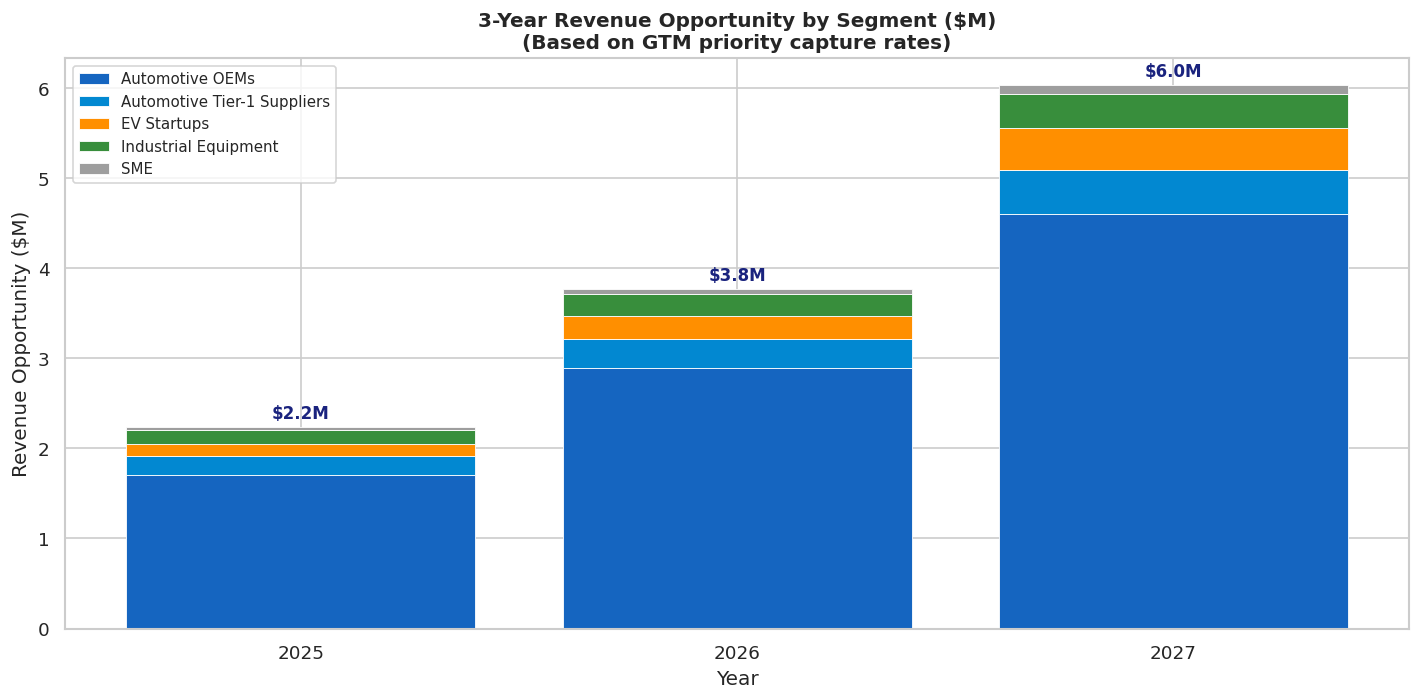

✅ Saved: chart_revenue_opportunity.png


In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates a stacked bar chart showing how the revenue opportunity
#   builds across segments and years.
#
# CHART CHOICE: Stacked bars are ideal for showing both:
#   - Year-over-year total growth (read the top of the stack)
#   - Segment contribution to each year's total (read the layers)
#
# The total value label above each bar makes it easy for a
# Sales Director to immediately see the year-over-year growth trend.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
years = [2025, 2026, 2027]
seg_colors = ['#1565C0', '#0288D1', '#FF8F00', '#388E3C', '#9E9E9E']
bottoms = np.zeros(3)   # Track bar bottom position for stacking

for i, segment in enumerate(pivot.index):
    # Get revenue values for this segment across all 3 years
    values = [df_opp[(df_opp['segment']==segment) & (df_opp['year']==y)]['revenue_opportunity_M'].values[0]
              for y in years]
    label  = segment.replace(' & New Entrants','').replace(' Manufacturers','')
    ax.bar(years, values, bottom=bottoms, color=seg_colors[i],
           label=label, edgecolor='white', linewidth=0.5)
    bottoms += np.array(values)   # Move the bottom up for next segment's stack

# Add total dollar labels above each year's bar
totals = df_opp.groupby('year')['revenue_opportunity_M'].sum()
for year, total in totals.items():
    ax.text(year, total+0.1, f'${total:.1f}M', ha='center',
            fontsize=10, fontweight='bold', color='#1A237E')

ax.set_title('3-Year Revenue Opportunity by Segment ($M)\n(Based on GTM priority capture rates)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue Opportunity ($M)')
ax.set_xticks(years)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart_revenue_opportunity.png', bbox_inches='tight')
plt.show()
print("✅ Saved: chart_revenue_opportunity.png")


## 3.4 — 🤖 AI Step: Gemini Generates GTM Strategies Per Segment

*Why AI here?* Once the priority segments are identified, a planner must draft a tailored strategy for each. Gemini generates a structured first draft — covering positioning, target accounts, actions, KPIs, and risks — in seconds. A human planner then reviews and refines it. This is the human-AI planning workflow.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   For each High Priority segment, sends a structured prompt to
#   Gemini AI containing the segment's data (spend, growth, pain
#   points, current vendors) and requests a tailored GTM strategy.
#
# AI TECHNIQUE: "Data-grounded prompting" — we inject actual
#   analysis outputs (scores, pain points, vendor data) directly
#   into the prompt. This grounds the AI response in our specific
#   market context rather than producing generic advice.
#
# OUTPUT FORMAT (per segment):
#   1. Positioning statement
#   2. Top 3 target account types
#   3. Key GTM actions (next 12 months)
#   4. Success KPIs
#   5. Main risk + mitigation
#
# BUSINESS VALUE:
#   This demonstrates how AI accelerates the planning cycle —
#   what might take a human analyst 2-3 days to draft can be
#   generated in seconds and then refined collaboratively.
# ============================================================

# Only generate strategies for High Priority segments (where resources should go)
top_segs = df_seg[df_seg['priority_tier'] == 'High Priority']['segment'].tolist()
gtm_strategies = {}

print("🤖 Gemini generating tailored GTM strategies for high-priority segments...\n")

for seg in top_segs:
    row = df_seg[df_seg['segment'] == seg].iloc[0]

    # Build a data-rich prompt with this segment's specific metrics
    prompt = f"""
You are a Strategic Business Planner at Dassault Systemes.
Create a specific, actionable GTM strategy for this high-priority segment.

Segment: {seg}
Market spend: ${row['annual_software_spend_usd_M']}M/year | Growth: {row['growth_rate_pct']}%/yr
Customer pain points: {row['pain_points']}
Current competing vendors: {row['current_vendors']}
GTM Priority Score: {row['gtm_priority_score']}/10

Provide:
1. Positioning statement (1 sentence — why Dassault Systemes wins here vs competitors)
2. Top 3 target account types within this segment
3. Key GTM actions for the next 12 months (3 specific bullet points)
4. Success KPIs (2 measurable metrics to track)
5. Main risk and how to mitigate it

Be concise and specific. Write as a Strategic Business Planner briefing a Sales Director.
"""
    strategy = gemini.generate_content(prompt).text
    gtm_strategies[seg] = strategy

    print(f"{'='*60}")
    print(f"GTM STRATEGY — {seg.upper()}")
    print(f"{'='*60}")
    print(strategy, "\n")


🤖 Gemini generating tailored GTM strategies for high-priority segments...

GTM STRATEGY — AUTOMOTIVE OEMS
**To:** Sales Director, Automotive Division
**From:** Strategic Business Planner, Dassault Systèmes
**Subject:** GTM Strategy: Accelerating EV Leadership in Automotive OEMs

### 1. Positioning Statement
Dassault Systèmes wins by delivering the **3DEXPERIENCE platform as a unified Virtual Twin**, closing the gap between systems engineering and multi-physics simulation to solve EV complexity 25% faster than the disconnected file-based workflows of Siemens NX or PTC Creo.

### 2. Top 3 Target Account Types
1.  **Legacy "Pivot" OEMs:** Established giants (e.g., Toyota, VW, Ford) currently re-tooling entire internal combustion lines for EV-only production.
2.  **EV "Pure Play" Challengers:** Rapidly scaling startups (e.g., Lucid, Rivian) requiring cloud-native, out-of-the-box PLM to avoid infrastructure debt.
3.  **Battery & Powertrain Tier 1s:** Strategic suppliers (e.g., LG Energy Sol

---
# 🔴 PHASE 4 — Executive Dashboard + Final Report

**Goal:** Package all analysis into boardroom-ready outputs — a multi-panel executive dashboard, a Tableau export, and an AI-written executive summary.

**Business context:** Analysis only creates value when it's communicated clearly to decision-makers. This phase shows the ability to translate technical work into executive-ready deliverables — a critical skill for any business analyst role.

## 4.1 — 4-Panel Executive Summary Dashboard

*Why this matters:* A Sales Director shouldn't need to read the entire notebook. This single dashboard gives the full story at a glance: which segments to prioritize, where competitors stand, and how big the revenue opportunity is.

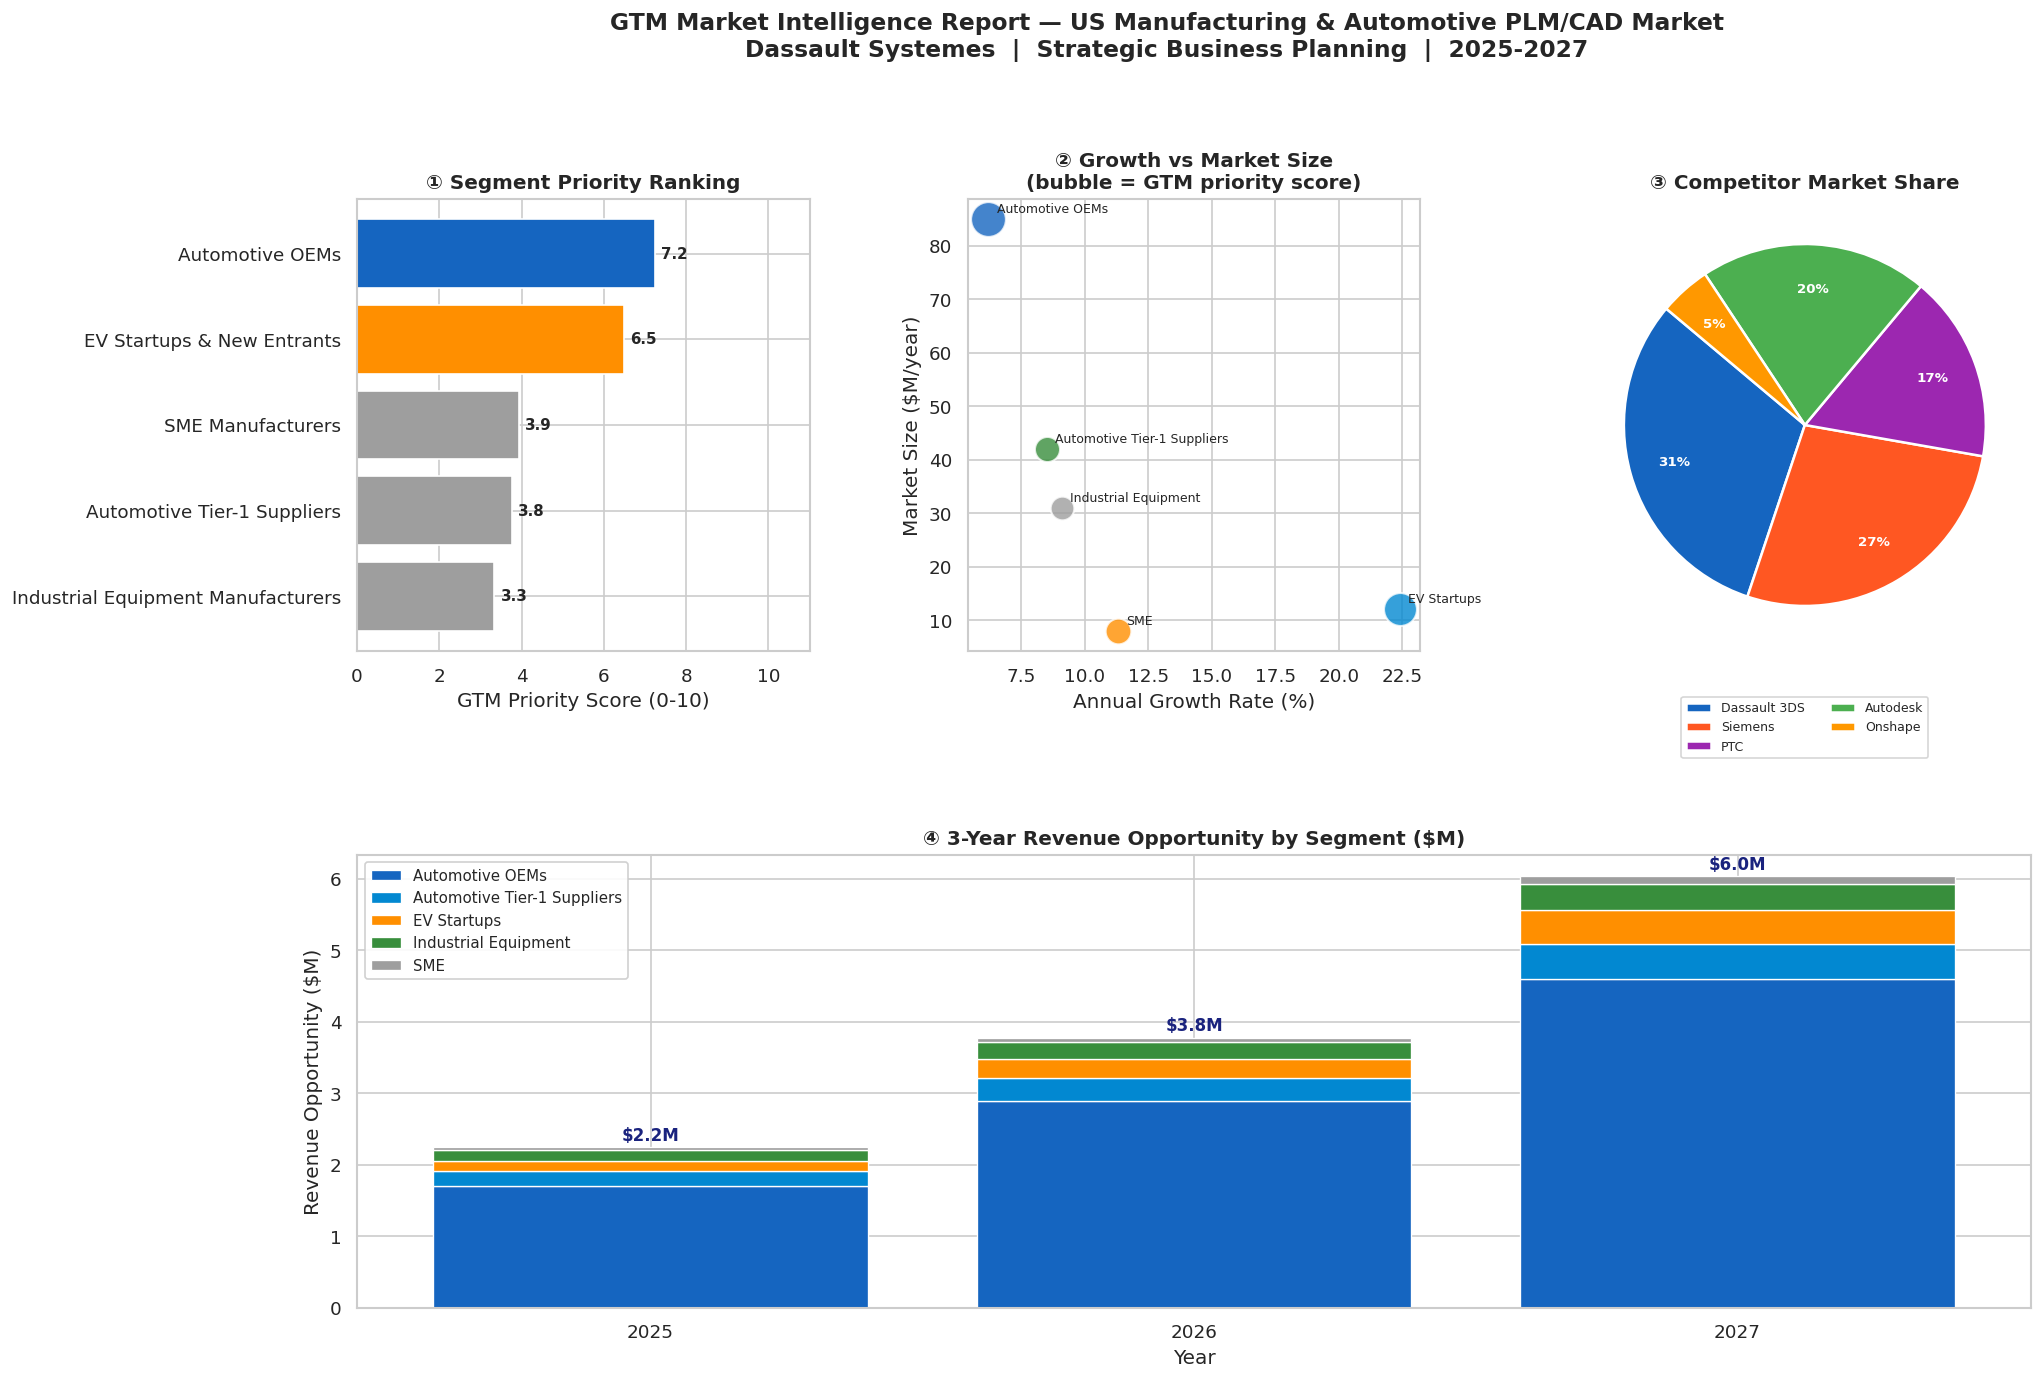

✅ Saved: executive_dashboard.png


In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Creates a professional 4-panel dashboard that summarizes the
#   entire project in one image — suitable for a PowerPoint deck
#   or a Sales Director briefing.
#
# THE 4 PANELS:
#   Panel ①: GTM Priority Ranking bar chart
#             → "Which segments should we focus on?"
#   Panel ②: Market size vs growth bubble chart
#             → "Where is the best combination of size and momentum?"
#   Panel ③: Competitor market share pie chart
#             → "Who controls the market today?"
#   Panel ④: 3-year revenue opportunity stacked bar
#             → "What is the dollar value of this strategy?"
#
# LAYOUT: Uses matplotlib GridSpec to create a 2-row, 3-column grid.
#   The bottom panel (revenue forecast) spans all 3 columns
#   to give it prominence as the most important output.
#
# EXPORT: Saved at 150 DPI for high-quality presentation use.
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'GTM Market Intelligence Report — US Manufacturing & Automotive PLM/CAD Market\n'
    'Dassault Systemes  |  Strategic Business Planning  |  2025-2027',
    fontsize=14, fontweight='bold', y=1.01
)
# GridSpec: 2 rows, 3 columns; bottom panel will span all 3 columns
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
tier_colors = {'High Priority': '#1565C0', 'Medium Priority': '#FF8F00', 'Low Priority': '#9E9E9E'}

# ── Panel ①: GTM Priority Ranking ──
ax1 = fig.add_subplot(gs[0, 0])
bc   = [tier_colors[str(t)] for t in df_seg['priority_tier']]
bars = ax1.barh(df_seg['segment'][::-1], df_seg['gtm_priority_score'][::-1], color=bc[::-1])
ax1.set_xlabel('GTM Priority Score (0-10)')
ax1.set_title('① Segment Priority Ranking', fontweight='bold')
ax1.set_xlim(0, 11)
for bar, val in zip(bars, df_seg['gtm_priority_score'][::-1]):
    ax1.text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

# ── Panel ②: Growth vs Market Size bubble chart ──
ax2 = fig.add_subplot(gs[0, 1])
cp2 = ['#1565C0', '#0288D1', '#FF8F00', '#388E3C', '#9E9E9E']
for i, row in df_seg.iterrows():
    ax2.scatter(row['growth_rate_pct'], row['annual_software_spend_usd_M'],
                s=row['gtm_priority_score']*60, color=cp2[i], alpha=0.8,
                edgecolors='white', linewidths=1.2)
    lbl = row['segment'].replace(' & New Entrants','').replace(' Manufacturers','')
    ax2.annotate(lbl, (row['growth_rate_pct'], row['annual_software_spend_usd_M']),
                 textcoords='offset points', xytext=(5,4), fontsize=7.5)
ax2.set_xlabel('Annual Growth Rate (%)')
ax2.set_ylabel('Market Size ($M/year)')
ax2.set_title('② Growth vs Market Size\n(bubble = GTM priority score)', fontweight='bold')

# ── Panel ③: Competitor market share pie chart ──
ax3 = fig.add_subplot(gs[0, 2])
pc  = ['#1565C0', '#FF5722', '#9C27B0', '#4CAF50', '#FF9800']
wedges, _, ats = ax3.pie(
    df_comp['market_share_pct'], labels=None, autopct='%1.0f%%',
    colors=pc, startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in ats:
    at.set_fontsize(8); at.set_fontweight('bold'); at.set_color('white')
sn = [v.replace(' Digital Industries','').replace(' Systemes (3DS)',' 3DS') for v in df_comp['vendor']]
ax3.legend(wedges, sn, loc='lower center', fontsize=7.5, bbox_to_anchor=(0.5,-0.25), ncol=2)
ax3.set_title('③ Competitor Market Share', fontweight='bold')

# ── Panel ④: 3-Year Revenue Opportunity (spans all 3 columns) ──
ax4 = fig.add_subplot(gs[1, :])   # gs[1, :] = second row, all columns
years = [2025, 2026, 2027]
sc    = ['#1565C0', '#0288D1', '#FF8F00', '#388E3C', '#9E9E9E']
bots  = np.zeros(3)
for i, segment in enumerate(pivot.index):
    vals = [df_opp[(df_opp['segment']==segment) & (df_opp['year']==y)]['revenue_opportunity_M'].values[0]
            for y in years]
    lbl  = segment.replace(' & New Entrants','').replace(' Manufacturers','')
    ax4.bar(years, vals, bottom=bots, color=sc[i], label=lbl, edgecolor='white', linewidth=0.8)
    bots += np.array(vals)
tots = df_opp.groupby('year')['revenue_opportunity_M'].sum()
for year, total in tots.items():
    ax4.text(year, total+0.1, f'${total:.1f}M', ha='center',
             fontsize=10, fontweight='bold', color='#1A237E')
ax4.set_title('④ 3-Year Revenue Opportunity by Segment ($M)', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue Opportunity ($M)')
ax4.set_xticks(years)
ax4.legend(loc='upper left', fontsize=9, framealpha=0.9)

# Save at high DPI for presentation-quality output
plt.savefig('executive_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: executive_dashboard.png")


## 4.2 — Export Tableau-Ready Excel File

*Why this matters:* Tableau is the standard BI tool used by analysts and business teams. Exporting clean, structured data to Excel with separate named sheets allows anyone to build interactive dashboards from this analysis — no Python knowledge required.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Exports all analysis outputs to a structured Excel workbook
#   with 3 separate sheets — formatted for direct import into
#   Tableau Public (free) or any other BI tool.
#
# THE 3 SHEETS:
#   Sheet 1 "Segment_Priority"    → GTM scores and tier rankings
#   Sheet 2 "Competitor_Landscape" → Competitor profiles and metrics
#   Sheet 3 "Revenue_Opportunity"  → 3-year revenue model by segment/year
# ============================================================

with pd.ExcelWriter('tableau_data_export.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Segment priority scores and GTM tier rankings
    df_seg[['segment', 'annual_software_spend_usd_M', 'growth_rate_pct',
            'gtm_priority_score', 'priority_tier', 'rank']].to_excel(
        writer, sheet_name='Segment_Priority', index=False)

    # Sheet 2: Competitor profiles for competitive landscape analysis
    df_comp[['vendor', 'market_share_pct', 'g2_rating', 'g2_reviews',
             'avg_deal_size_usd_K', 'cloud_native']].to_excel(
        writer, sheet_name='Competitor_Landscape', index=False)

    # Sheet 3: Full 3-year revenue opportunity model
    df_opp.to_excel(writer, sheet_name='Revenue_Opportunity', index=False)

print("✅ Saved: tableau_data_export.xlsx")
print("   → 3 sheets: Segment_Priority | Competitor_Landscape | Revenue_Opportunity")
print("   → Import into Tableau Public (free) at https://public.tableau.com")


✅ Saved: tableau_data_export.xlsx
   → 3 sheets: Segment_Priority | Competitor_Landscape | Revenue_Opportunity
   → Import into Tableau Public (free) at https://public.tableau.com


## 4.3 — 🤖 AI Step: Gemini Writes the Executive Summary

*Why AI here?* The executive summary is the most-read document in any strategic planning package. It must be clear, structured, and written for a senior audience. We provide Gemini with all the key data outputs from our analysis and ask it to draft the summary — demonstrating how AI accelerates business communication.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Uses Gemini AI to write a professional executive summary
#   based on all the data and insights generated in this project.
#
# PROMPT DESIGN: "Data injection + structured output"
#   We pass in the actual numbers from our analysis (market size,
#   revenue opportunity, top segments) so Gemini generates a
#   summary grounded in our specific findings — not generic text.
#
#   The output format (Situation / Findings / Actions / KPIs / Vision)
#   mirrors the structure used in real strategic planning documents
#   at enterprise software companies.
#
# OUTPUT: Saved as executive_summary.md (Markdown format)
#   → Can be converted to PDF or pasted into PowerPoint
# ============================================================

# Pull key numbers from our analysis to inject into the prompt
total_opp = df_opp['revenue_opportunity_M'].sum()
top_seg   = df_seg.iloc[0]   # Highest-ranked segment

prompt = f"""
You are a Strategic Business Planner at Dassault Systemes.
Write a professional 1-page executive summary for a Sales Director
based on the following GTM market intelligence analysis results.

Analysis Data:
- Total addressable market analyzed: ${int(df_seg['annual_software_spend_usd_M'].sum())}M/year
- 3-year GTM revenue opportunity identified: ${round(total_opp,1)}M
- #1 priority segment: {top_seg['segment']} (GTM score: {top_seg['gtm_priority_score']}/10, growth: {top_seg['growth_rate_pct']}%/yr)
- #2 priority segment: {df_seg.iloc[1]['segment']}
- 5 major competitors analyzed; Dassault leads with 28.4% market share
- Customer sentiment analysis run on 18 reviews across 3 vendor/segment pairs
- AI-generated GTM strategies produced for all high-priority segments

Required structure:
## Executive Summary
**Situation** (2-3 sentences: what is the market context?)
**Key Findings** (3 bullet points: most important insights from the analysis)
**Recommended GTM Actions** (3 specific actions for the next 6 months)
**12-Month Targets** (2 measurable KPIs to track success)
**3-Year Vision** (1 paragraph: where should Dassault Systemes be positioned by 2027?)

Write in a concise, confident, boardroom-ready tone.
"""

exec_summary = gemini.generate_content(prompt).text
print(exec_summary)

# Save to markdown file
with open('executive_summary.md', 'w') as f:
    f.write("# GTM Market Intelligence — Executive Summary\n")
    f.write("**Dassault Systemes | US Manufacturing & Automotive | 2025-2027**\n\n")
    f.write(exec_summary)
print("\n✅ Saved: executive_summary.md")


## Executive Summary

**Situation**
The global automotive sector is undergoing a rapid transition toward software-defined vehicles and electrification, representing a total addressable market (TAM) of $178M annually. As the current market leader with a 28.4% share, Dassault Systèmes is positioned to capture a high-velocity $12.0M three-year revenue opportunity by intensifying our focus on legacy OEM modernization and the burgeoning EV startup ecosystem.

**Key Findings**
*   **High-Yield Segment Prioritization:** Automotive OEMs remain our primary growth engine (GTM score: 7.25/10), exhibiting a resilient 6.2% annual growth rate as they retool for sustainable mobility.
*   **Competitive Dominance:** Dassault Systèmes leads a field of five major competitors with a 28.4% market share; however, maintaining this lead requires addressing specific customer sentiment trends identified in recent vendor evaluations.
*   **Emerging Disruptors:** EV Startups and New Entrants have been identified 

## 4.4 — 🤖 AI Step: Gemini Writes the GitHub README

*Why this matters:* The README is the first thing a recruiter or hiring manager sees when they open the GitHub repo. It should clearly explain what the project does, what tools were used, and what skills it demonstrates — all in a professional, scannable format.

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Uses Gemini AI to generate a professional GitHub README.md
#   for this project. The README is the front page of the repo
#   and the first thing a recruiter sees.
#
# A GOOD README INCLUDES:
#   - Project title and 1-line description
#   - Business context (what problem does it solve?)
#   - Tech stack with badges
#   - Repo structure (what files are in the repo?)
#   - How to run instructions
#   - Key outputs / screenshots
#   - Skills demonstrated
#
# EXPECTED OUTPUT: Professional README in Markdown format
#   → Saved as README.md
# ============================================================

prompt = """
Write a professional GitHub README.md for a data/business analyst portfolio project.

Project Title: AI-Powered GTM Market Intelligence — PLM/CAD Market
Author: Sunanda Guha

Tech stack (all free and open-source):
- Python 3, Pandas, NumPy (data analysis and modeling)
- Google Gemini API via google-generativeai (AI competitor intelligence, strategy generation)
- HuggingFace Transformers — DistilBERT (NLP sentiment analysis, runs locally)
- Matplotlib, Seaborn (data visualization and executive dashboards)
- Tableau Public (interactive dashboard, free)
- Google Colab (free cloud Python environment)

Project covers end-to-end:
1. Market segmentation and competitive landscape analysis
2. AI-powered competitor intelligence (Gemini API)
3. NLP sentiment analysis on customer reviews (HuggingFace DistilBERT)
4. Weighted GTM territory scoring model (5-factor, Python)
5. 3-year revenue opportunity modeling
6. AI-generated GTM strategies per priority segment
7. 4-panel executive summary dashboard (Matplotlib)
8. Tableau-ready data export
9. AI-written executive summary report

Include in the README:
- Project overview and business context
- Tech stack badges (use shields.io style)
- Repo folder/file structure
- Step-by-step instructions to run in Google Colab
- Description of key outputs with chart names
- Skills demonstrated section
- A note about the Tableau Public dashboard (placeholder link)

Keep it concise, professional, and formatted for GitHub Markdown rendering.
"""

readme = gemini.generate_content(prompt).text
with open('README.md', 'w') as f:
    f.write(readme)
print(readme)
print("\n✅ Saved: README.md")


This is a professional, recruiter-ready `README.md` template tailored for your project. You can copy the code block below directly into your GitHub repository.

***

# AI-Powered GTM Market Intelligence — PLM/CAD Market
**Author:** Sunanda Guha  
**Role:** Data/Business Analyst  

![Python](https://img.shields.io/badge/python-3670A0?style=for-the-badge&logo=python&logoColor=ffdd54)
![Google Gemini](https://img.shields.io/badge/Google%20Gemini-4285F4?style=for-the-badge&logo=google&logoColor=white)
![HuggingFace](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-FFD21E?style=for-the-badge)
![Pandas](https://img.shields.io/badge/pandas-%23150458.svg?style=for-the-badge&logo=pandas&logoColor=white)
![Tableau](https://img.shields.io/badge/Tableau-E97627?style=for-the-badge&logo=Tableau&logoColor=white)

## 📌 Project Overview
This project provides an end-to-end Go-To-Market (GTM) strategy framework for the Product Lifecycle Management (PLM) and CAD software industry. By combining t

## 4.5 — ⬇️ Download All Outputs

*All files will download automatically to your computer. Then follow the GitHub upload steps in the resume guide.*

In [ ]:
# ============================================================
# WHAT THIS DOES:
#   Downloads all project output files from Colab to your local
#   computer using google.colab.files.download().
#
# FILES DOWNLOADED:
#   Charts (PNG):
#     chart_market_overview.png       — Phase 2: market size & growth
#     chart_competitive_landscape.png — Phase 2: competitive bubble chart
#     chart_sentiment.png             — Phase 2: NLP sentiment results
#     chart_gtm_priority.png          — Phase 3: scoring model + heatmap
#     chart_revenue_opportunity.png   — Phase 3: 3-year revenue stacked bar
#     executive_dashboard.png         — Phase 4: 4-panel summary dashboard
#
#   Data & Reports:
#     tableau_data_export.xlsx        — Import into Tableau Public
#     executive_summary.md            — AI-written strategic summary
#     README.md                       — GitHub repo front page
#
# NEXT STEPS AFTER DOWNLOADING:
#   1. Go to https://public.tableau.com (free) → upload the Excel file
#      → build 2 views → publish
# ============================================================

from google.colab import files

output_files = [
    'chart_market_overview.png',
    'chart_competitive_landscape.png',
    'chart_sentiment.png',
    'chart_gtm_priority.png',
    'chart_revenue_opportunity.png',
    'executive_dashboard.png',
    'tableau_data_export.xlsx',
    'executive_summary.md',
    'README.md',
]

print("⬇️  Downloading all project outputs...\n")
for fname in output_files:
    files.download(fname)
    print(f"  ✅  {fname}")


⬇️  Downloading all project outputs...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  chart_market_overview.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅  executive_summary.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  README.md
